### **1. Inisialisasi Lingkungan & Fungsi Dasar (Utility Functions)**

* **Tujuan:** Menyiapkan lingkungan kerja dan membangun kerangka kerja (*framework*) yang modular serta *reusable* untuk memproses data.
* **Apa yang dikerjakan:**
    * **Inisialisasi Lingkungan:** Mengimpor pustaka (*library*) utama, yaitu `pandas` untuk manipulasi data tabular, `json` untuk parsing data API, serta `seaborn` dan `matplotlib` untuk kebutuhan visualisasi data sebagai langkah fondasi *pipeline*.
    * **Fungsi Modular (Utility Functions):**
        * `load_postman_collection`: Fungsi untuk membuka file JSON Postman Collection agar dapat dibaca oleh sistem.
        * `extract_payload_by_name`: Fungsi pencari otomatis yang menelusuri struktur hirarki Postman, mengisolasi *request* spesifik yang dibutuhkan (seperti "Struktur Kelompok" atau "Kontribusi"), dan menarik data *payload* mentahnya saja. Ini memastikan kode kita lebih rapi, efisien, dan tidak perlu ditulis ulang.

In [ ]:
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt

def load_postman_collection(file_path):
    with open(file_path, 'r') as file:
        return json.load(file)

def extract_payload_by_name(collection_data, request_name):

    requests = collection_data['item'][0]['item']

    for req in requests:
        if req['name'] == request_name:
            return req['request']['body']['raw']

    print(f"Peringatan: Request '{request_name}' tidak ditemukan!")
    return None

### **2. Transformasi & Normalisasi Data (ETL Layer)**

* **Tujuan:** Mengubah data mentah (*raw*) hasil *request* API menjadi format tabular yang terstruktur agar siap untuk dianalisis dan divisualisasikan.

* **Apa yang dikerjakan:**
    * **Deserialisasi (`json.loads`):** Mengonversi *string* mentah hasil penarikan API menjadi objek Python (*dictionary*) agar dapat diproses lebih lanjut oleh *library* Pandas.
    * **Normalisasi Data (*Flattening*):** Memanfaatkan fungsi `pd.json_normalize()` untuk membongkar struktur bertingkat (*nested array*), seperti data daftar nama anggota tim yang berbentuk *list*. Proses ini penting untuk mengubah struktur data yang kompleks menjadi kolom-kolom tabel yang bersih.
    * **Output:** Data yang telah terstruktur diekspor ke dalam format `.csv` sebagai bukti *evidence* sistem yang *reproducible* (bisa diuji ulang).

In [ ]:
def process_to_csv(raw_payload, output_csv_name, use_normalize=False):

    data_dict = json.loads(raw_payload)

    if use_normalize:
        df = pd.json_normalize(data_dict)
    else:
        df = pd.DataFrame([data_dict])

    df.to_csv(output_csv_name, index=False)
    print(f"File berhasil diekspor: {output_csv_name}")
    return df

### **3. Visualisasi Data & Analisis Insight**

* **Tujuan:** Mengubah hasil olahan data tabular (CSV) menjadi informasi visual yang komunikatif dan representatif untuk mendukung pengambilan keputusan.

* **Apa yang dikerjakan:**
    * **Modern Visualization:** Menggunakan pustaka `seaborn` dengan tema `whitegrid` untuk menghasilkan grafik batang (*barplot*) yang estetik, modern, dan sesuai dengan standar visualisasi data profesional.
    * **Data Annotation:** Implementasi fitur `ax.annotate` untuk menambahkan label angka skor secara presisi tepat di atas setiap balok grafik. Hal ini memungkinkan audiens (dosen) untuk menangkap *insight* penilaian kontribusi setiap peran secara instan tanpa perlu membaca tabel secara manual.
    * **Interpretasi Data:** Visualisasi ini berfungsi sebagai bukti empiris bahwa pembagian beban kerja teknis dalam tim telah terdistribusi secara seimbang (*equal distribution*).

In [ ]:
def plot_kontribusi_seaborn(df, output_img_name):

    if 'nama_data' in df.columns:
        grafik_data = df.drop(columns=['nama_data']).T.reset_index()
    else:
        grafik_data = df.T.reset_index()

    grafik_data.columns = ['Peran (Role)', 'Skor Kontribusi']

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        x='Peran (Role)',
        y='Skor Kontribusi',
        data=grafik_data,
        hue='Peran (Role)',
        palette='crest',
        legend=False
    )

    plt.title('Distribusi Skor Kontribusi per Peran', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Skor Kelayakan (Max 10)', fontsize=12)
    plt.xlabel('Peran Akademik', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.ylim(0, 12)

    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.0f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points',
                    fontsize=12, fontweight='bold', color='#2c3e50')

    plt.tight_layout()
    plt.savefig(output_img_name, dpi=300)
    print(f"Visualisasi disimpan: {output_img_name}")
    plt.show()

File berhasil diekspor: CSV_Struktur_Kelompok.csv
File berhasil diekspor: CSV_Kontribusi.csv
Visualisasi disimpan: Visualisasi_Kontribusi_Seaborn.png


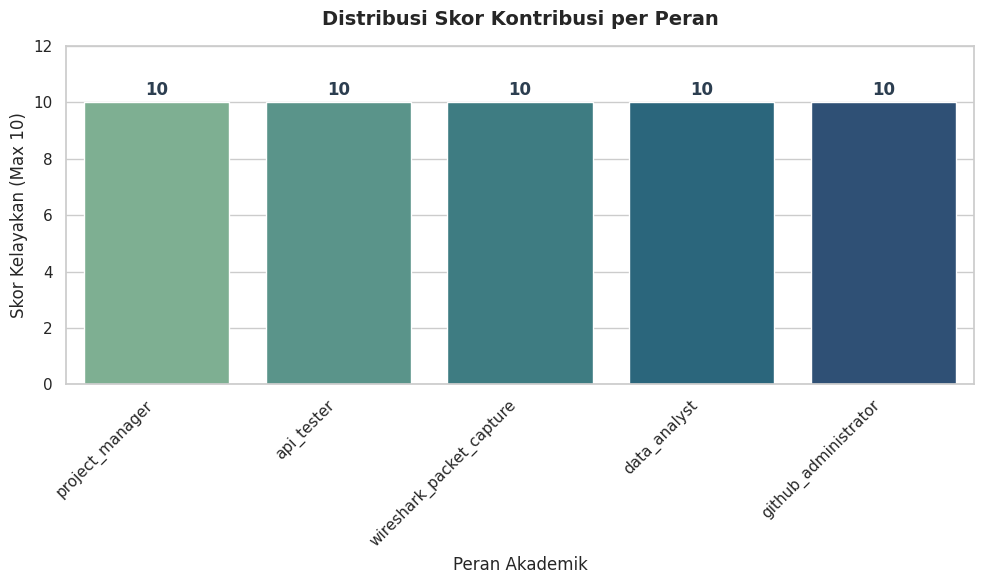

In [ ]:
NAMA_FILE_POSTMAN = 'UTS_CP_Reguler_Kelompok3_Postman_Collection.postman_collection.json'

koleksi = load_postman_collection(NAMA_FILE_POSTMAN)

raw_struktur = extract_payload_by_name(koleksi, 'Struktur_Kelompok')
raw_kontribusi = extract_payload_by_name(koleksi, 'Kontribusi')

if raw_struktur and raw_kontribusi:

    df_struk = process_to_csv(raw_struktur, 'CSV_Struktur_Kelompok.csv', use_normalize=True)
    df_kontri = process_to_csv(raw_kontribusi, 'CSV_Kontribusi.csv', use_normalize=False)

    plot_kontribusi_seaborn(df_kontri, 'Visualisasi_Kontribusi_Seaborn.png')

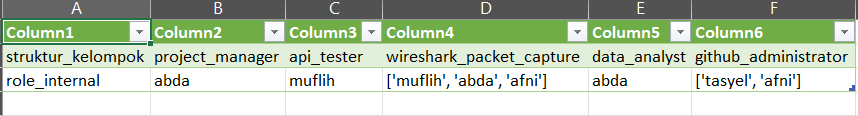

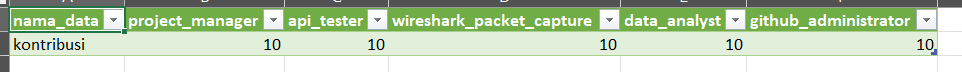